# 04. Avaliação de Métricas de Alerta e Explicabilidade

Este notebook avalia o desempenho do detector de anomalias no conjunto de teste de 2024 (que contém a simulação da Grande Enchente do RS ocorrendo em Maio/2024). Calculamos as métricas de alerta (F2-score e Lead Time) e investigamos quais features geraram o alerta.

In [4]:
import os
import sys
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

sys.path.append(os.path.abspath('..'))

## 1. Carregando o Modelo e Dados de Teste Rotulados

In [7]:
df_test = pd.read_csv('../data/processed/test_labeled.csv')
df_test['timestamp'] = pd.to_datetime(df_test['timestamp'])

#model = tf.keras.models.load_model('../models/lstm_ae_rs_v1.h5')

model = tf.keras.models.load_model(
    '../models/lstm_ae_rs_v1.h5', 
    custom_objects={'mae': tf.keras.metrics.MeanAbsoluteError()}
)

with open('../models/thresholds_rs_v1.json', 'r') as f:
    thresholds = json.load(f)
    
features = ['precipitacao', 'nivel_rio', 'velocidade_vento', 'temperatura', 'umidade', 'pressao', 'vazao']
window = 72

## 2. Calculando Erros de Reconstrução no Conjunto de Teste

In [8]:
from src.data.preprocess import create_sequences
from src.model.anomaly import reconstruction_error

X_test = create_sequences(df_test, features, window=window)
test_errors = reconstruction_error(model, X_test)

# Alinhar timestamps e rótulos reais com as janelas temporais de 72h
test_timestamps = df_test['timestamp'].values[window-1:]
y_true = df_test['is_anomaly'].values[window-1:]

## 3. Mapeando Limiares Sazonais ao Longo do Teste

In [14]:
from src.model.anomaly import get_season

seasonal_th = thresholds['seasonal']
global_th = thresholds['global_p97']

test_th_array = []
for ts_val in pd.to_datetime(test_timestamps):
    season = get_season(ts_val.month)
    test_th_array.append(seasonal_th.get(season, global_th))
    
test_th_array = np.array(test_th_array)

## 4. Visualizando a Curva de Reconstrução vs Threshold Sazonal

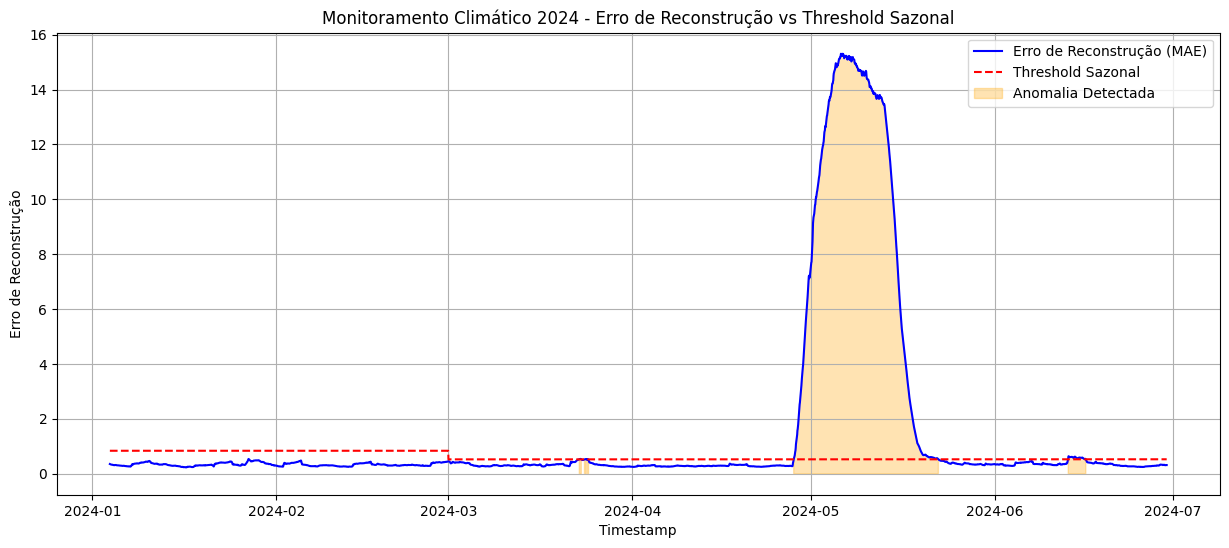

In [19]:
plt.figure(figsize=(15, 6))
plt.plot(test_timestamps, test_errors, label='Erro de Reconstrução (MAE)', color='blue')
plt.plot(test_timestamps, test_th_array, label='Threshold Sazonal', color='red', linestyle='--')
plt.fill_between(test_timestamps, 0, test_errors, where=(test_errors > test_th_array), color='orange', alpha=0.3, label='Anomalia Detectada')

plt.title('Monitoramento Climático 2024 - Erro de Reconstrução vs Threshold Sazonal')
plt.xlabel('Timestamp')
plt.ylabel('Erro de Reconstrução')
plt.legend()
plt.grid(True)
plt.show()

## 5. Cálculo das Métricas de Validação (F2-score, Precision, Recall)

In [20]:
from src.evaluation.metrics import evaluate_anomaly_detector

metrics_dict = evaluate_anomaly_detector(y_true, test_errors, test_th_array)
print("Métricas de Classificação no Conjunto de Teste:")
for metric_name, val in metrics_dict.items():
    if metric_name != 'confusion_matrix':
        print(f"- {metric_name.upper()}: {val}")
print("Matriz de Confusão:", metrics_dict['confusion_matrix'])

Métricas de Classificação no Conjunto de Teste:
- PRECISION: 0.8083
- RECALL: 0.9928
- F1: 0.8911
- F2: 0.9494
- FAR: 0.0349
- AUROC: 0.9984
- AUPRC: 0.9955
Matriz de Confusão: [[3592, 130], [4, 548]]


## 6. Cálculo do Lead Time Operacional (Alerta Prévio)

In [21]:
from src.evaluation.metrics import compute_lead_time

# Identifica momentos de ativação do alerta do modelo
alerts_mask = test_errors > test_th_array
alert_timestamps = pd.to_datetime(test_timestamps)[alerts_mask]

# Pico da enchente de Maio de 2024 injetada
event_peaks = [pd.Timestamp('2024-05-04 12:00:00')]

lead_metrics = compute_lead_time(alert_timestamps, event_peaks, tolerance_hours=72)
print("Métricas de Alerta Prévio (Lead Time):")
for k, v in lead_metrics.items():
    print(f"- {k}: {v}")

Métricas de Alerta Prévio (Lead Time):
- mean_lead_hours: 72.0
- median_lead_hours: 72.0
- min_lead_hours: 72.0
- events_detected: 1
- events_missed: 0


## 7. Explicabilidade da Anomalia

In [22]:
from src.evaluation.explainability import explain_anomaly

# Seleciona a janela onde ocorreu o erro máximo (pico da anomalia)
max_err_idx = np.argmax(test_errors)
worst_window_scaled = X_test[max_err_idx]
worst_timestamp = pd.to_datetime(test_timestamps)[max_err_idx]

print(f"Explicando a anomalia em {worst_timestamp}:")
explanation = explain_anomaly(model, worst_window_scaled, features)
explanation

Explicando a anomalia em 2024-05-06 03:00:00:


,feature,reconstruction_error,contribution_pct
6,vazao,57.281393,53.47
0,precipitacao,19.992630,18.66
1,nivel_rio,15.520607,14.49
5,pressao,6.454807,6.02
2,velocidade_vento,5.051854,4.72
4,umidade,2.316326,2.16
3,temperatura,0.516220,0.48
